In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

### Part#1

In [ ]:
df = pd.read_csv("/content/hospital_readmission_risk_10000.csv")
df.head()

,patient_id,age,gender,weight_kg,height_cm,bmi,num_previous_admissions,chronic_conditions,medications_count,last_hemoglobin,...,length_of_stay,procedures_count,smoking_status,alcohol_use,physical_activity,insurance_type,followup_compliance,social_support,mental_health_issue,readmission_risk
0,d8fd1a56-a5d8-499b-917c-f9ac8d369f9b,18,Male,57,157,23.1,8,Heart Disease,8,16.2,...,7,0,Current,Moderate,Medium,Private,Poor,Weak,Yes,Medium
1,2e9b4349-69e5-494f-b806-947ec5b5bb7c,23,Female,117,150,52.0,6,Diabetes,6,13.1,...,21,2,Never,High,Medium,Private,Good,Weak,Yes,High
2,6f279c22-3b20-4328-9dac-466de7c47a51,80,Female,61,141,30.7,5,Heart Disease,8,15.4,...,2,0,Never,Moderate,Low,Public,Good,Weak,No,Low
3,1af43d48-79a9-4408-a1f1-13c58d7221fd,15,Female,47,164,17.5,0,Hypertension,1,14.2,...,8,3,Former,NaN,High,Private,Good,Weak,No,High
4,e7903dbe-839e-4ea6-a6d0-83438a981a9b,14,Male,67,179,20.9,6,Heart Disease,0,14.7,...,3,0,Former,High,High,Uninsured,Poor,Weak,No,Medium


### Part#2

In [ ]:
df.drop_duplicates(inplace=True)
print(f"After removing duplicates: {df.shape[0]} rows")

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

for col in numerical_cols: df[col].fillna(df[col].median(), inplace=True)
for col in categorical_cols: df[col].fillna(df[col].mode()[0], inplace=True)

print(f"Missing values handled.\n")

target = "readmission_risk"
if target not in df.columns:
    target = df.columns[-1]
    print(f"Target column not found. Using last column: '{target}'")

feature_cols = [c for c in df.columns if c != target]
X_raw = df[feature_cols].copy()
y_raw = df[target].copy()

categorical_features = X_raw.select_dtypes(include=["object"]).columns.tolist()
for col in categorical_features:
    le = LabelEncoder()
    X_raw[col] = le.fit_transform(X_raw[col].astype(str))

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw.astype(str))
num_classes = len(label_encoder.classes_)
print(f"Target classes ({num_classes}): {list(label_encoder.classes_)}\n")

X = X_raw.values.astype(np.float32)
y = y_encoded.astype(np.int64)

# 80/20 Split
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

print(f"Training set: {X_train_full.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Features: {X_train_full.shape[1]}\n")

input_dim = X_train_full.shape[1]

After removing duplicates: 9999 rows
Missing values handled.

Target classes (3): ['High', 'Low', 'Medium']

Training set: 7999 samples
Test set: 2000 samples
Features: 22



In [ ]:
def make_loaders(X_train, y_train, batch_size=32, val_split=0.2):

    X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=val_split, random_state=42, stratify=y_train)

    train_dataset = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr))
    val_dataset = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    return train_loader, val_loader


def evaluate(model, X_data, y_data):
    model.eval()
    with torch.no_grad():
        predictions = model(torch.tensor(X_data))
        predicted_classes = predictions.argmax(dim=1).numpy()

    accuracy = accuracy_score(y_data, predicted_classes)
    return accuracy


def train_with_early_stopping(model, X_train, y_train, patience=5, epochs=100, batch_size=32, val_split=0.2, verbose=True):

    optimizer = optim.Adam(model.parameters())
    loss_fn = nn.CrossEntropyLoss()

    train_loader, val_loader = make_loaders(X_train, y_train, batch_size, val_split)

    best_val_loss = float("inf")
    patience_counter = 0
    best_model_weights = None

    train_losses = []
    val_losses = []

    for epoch in range(1, epochs + 1):

        # -> TRAINING
        model.train()
        train_loss_total = 0.0

        for batch_X, batch_y in train_loader:
            # Forward pass
            logits = model(batch_X)
            loss = loss_fn(logits, batch_y)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss_total += loss.item() * len(batch_X)

        avg_train_loss = train_loss_total / len(train_loader.dataset)

        # -> VALIDATION
        model.eval()
        val_loss_total = 0.0

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                logits = model(batch_X)
                loss = loss_fn(logits, batch_y)
                val_loss_total += loss.item() * len(batch_X)

        avg_val_loss = val_loss_total / len(val_loader.dataset)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        if verbose and epoch % 10 == 0: print(f"  Epoch {epoch:3d}: train_loss={avg_train_loss:.4f}  val_loss={avg_val_loss:.4f}")

        # -> EARLY STOPPING CHECK
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            bestM = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if verbose: print(f"  Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
                break

    model.load_state_dict(bestM)

    return train_losses, val_losses, epoch

In [ ]:
def plot_curves(train_losses, val_losses, title):
    plt.figure(figsize=(9, 5))

    plt.plot(train_losses, label="Training Loss", linewidth=2.5, marker='o', markersize=4)
    plt.plot(val_losses, label="Validation Loss", linewidth=2.5, marker='s', markersize=4)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.grid('True')
    plt.show()

### Part#3

In [ ]:
class SimpleNet(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes),
        )

    def forward(self, x): return self.net(x)

### Part#4

In [ ]:
simple_model = SimpleNet(input_dim, num_classes)
tr_losses, val_losses, stopped_epoch = train_with_early_stopping(
    simple_model, X_train_full, y_train_full,
    patience=5, epochs=100, batch_size=32, val_split=0.2
)

  Early stopping at epoch 6 (no improvement for 5 epochs)


### Part#5

Learning Curves (Simple Model)


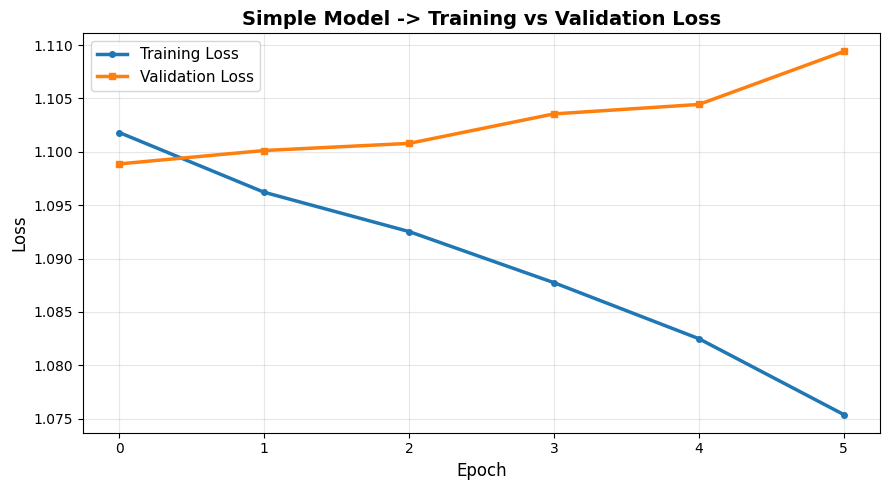

No significant overfitting detected.


In [ ]:
print("Learning Curves (Simple Model)")
plot_curves(tr_losses, val_losses, "Simple Model -> Training vs Validation Loss")

# Overfitting check
if val_losses[-1] > min(val_losses) * 1.05: print("  → Overfitting detected: validation loss rose after its minimum.")
else: print("No significant overfitting detected.")

### Part#6

In [ ]:
S_test_acc = evaluate(simple_model, X_test, y_test)
print(f"Simple Model Test Accuracy: {S_test_acc*100:.2f}%")

Simple Model Test Accuracy: 32.15%


### Part#7

Dropout Model Training with Early Stopping
  Early stopping at epoch 9 (no improvement for 5 epochs)


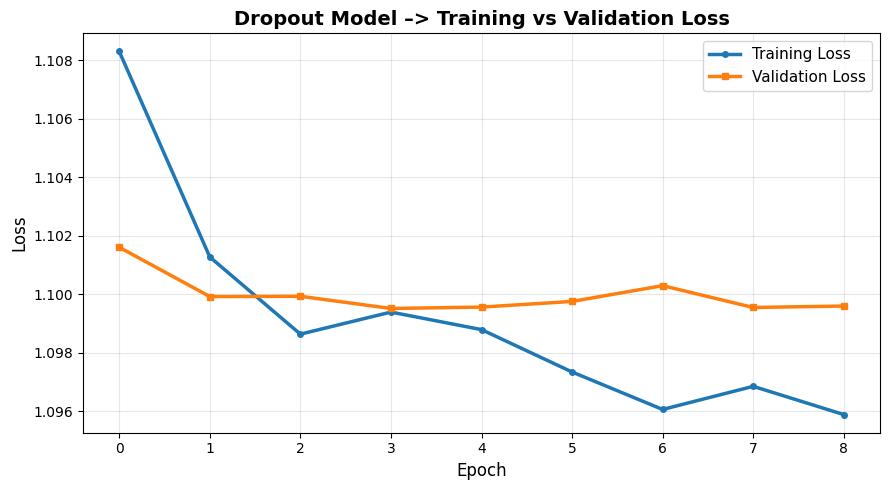

Dropout Model Test Accuracy: 32.10%


In [ ]:
class DropoutNet(nn.Module):
    def __init__(self, input_dim, num_classes, drop_rate=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(drop_rate),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(drop_rate),
            nn.Linear(32, num_classes),
        )

    def forward(self, x): return self.net(x)


print("Dropout Model Training with Early Stopping")

dropout_model = DropoutNet(input_dim, num_classes)
tr_losses_d, val_losses_d, stopped_epoch_d = train_with_early_stopping(
    dropout_model, X_train_full, y_train_full, patience=5, epochs=100, batch_size=32, val_split=0.2
)

plot_curves(tr_losses_d, val_losses_d, "Dropout Model –> Training vs Validation Loss")

D_test_acc = evaluate(dropout_model, X_test, y_test)
print(f"Dropout Model Test Accuracy: {D_test_acc*100:.2f}%")

### Part#8

In [ ]:
print("-> K-FOLD CROSS VALIDATION (K=5)")

K = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

def kfold_pytorch(ModelClass, X_all, y_all, model_kwargs, model_name):
    fold_train_accs, fold_val_accs = [], []

    for fold_num, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all), 1):

        X_fold_train = X_all[train_idx]
        X_fold_val = X_all[val_idx]
        y_fold_train = y_all[train_idx]
        y_fold_val = y_all[val_idx]

        scaler_fold = StandardScaler()
        X_fold_train = scaler_fold.fit_transform(X_fold_train).astype(np.float32)
        X_fold_val = scaler_fold.transform(X_fold_val).astype(np.float32)

        model = ModelClass(**model_kwargs)
        train_with_early_stopping(
            model, X_fold_train, y_fold_train,
            patience=5, epochs=100, batch_size=32,
            val_split=0.2, verbose=False
        )

        train_acc = evaluate(model, X_fold_train, y_fold_train)
        val_acc = evaluate(model, X_fold_val, y_fold_val)

        fold_train_accs.append(train_acc)
        fold_val_accs.append(val_acc)

        print(f"  Fold {fold_num}: train_acc={train_acc*100:.2f}%  val_acc={val_acc*100:.2f}%")

    return fold_train_accs, fold_val_accs


# Train Simple Model with K-Fold CV
print("\nSimple Neural Network (No Dropout):")
simple_train_accs, simple_val_accs = kfold_pytorch(
    SimpleNet, X_train_full, y_train_full,
    {"input_dim": input_dim, "num_classes": num_classes}, "SimpleNet"
)

print(f"\nSimple Model -> Average train acc: {np.mean(simple_train_accs)*100:.2f}%")
print(f"Simple Model -> Average val acc: {np.mean(simple_val_accs)*100:.2f}%")

# Train Dropout Model with K-Fold CV
print("Dropout Neural Network:")
dropout_train_accs, dropout_val_accs = kfold_pytorch(
    DropoutNet, X_train_full, y_train_full,
    {"input_dim": input_dim, "num_classes": num_classes}, "DropoutNet"
)

print(f"\nDropout Model -> Average train acc: {np.mean(dropout_train_accs)*100:.2f}%")
print(f"Dropout Model -> Average val acc: {np.mean(dropout_val_accs)*100:.2f}%")

-> K-FOLD CROSS VALIDATION (K=5)

Simple Neural Network (No Dropout):
  Fold 1: train_acc=36.72%  val_acc=33.06%
  Fold 2: train_acc=36.44%  val_acc=34.00%
  Fold 3: train_acc=35.97%  val_acc=35.06%
  Fold 4: train_acc=38.35%  val_acc=31.50%
  Fold 5: train_acc=37.50%  val_acc=33.02%

Simple Model -> Average train acc: 37.00%
Simple Model -> Average val acc: 33.33%
Dropout Neural Network:
  Fold 1: train_acc=38.29%  val_acc=30.88%
  Fold 2: train_acc=38.83%  val_acc=33.69%
  Fold 3: train_acc=37.27%  val_acc=33.81%
  Fold 4: train_acc=36.93%  val_acc=34.12%
  Fold 5: train_acc=38.20%  val_acc=33.40%

Dropout Model -> Average train acc: 37.90%
Dropout Model -> Average val acc: 33.18%


### Part#9

In [ ]:
print("-> SCIKIT-LEARN: LOGISTIC REGRESSION + 5-FOLD CV")

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_train_accs, lr_val_accs = [], []

for fold_num, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full), 1):

    X_fold_train, X_fold_val = X_train_full[train_idx], X_train_full[val_idx]
    y_fold_train, y_fold_val = y_train_full[train_idx], y_train_full[val_idx]


    scaler_fold = StandardScaler()
    X_fold_train = scaler_fold.fit_transform(X_fold_train)
    X_fold_val = scaler_fold.transform(X_fold_val)

    lr_model.fit(X_fold_train, y_fold_train)

    train_acc = accuracy_score(y_fold_train, lr_model.predict(X_fold_train))
    val_acc = accuracy_score(y_fold_val, lr_model.predict(X_fold_val))

    lr_train_accs.append(train_acc)
    lr_val_accs.append(val_acc)

    print(f"  Fold {fold_num}: train_acc={train_acc*100:.2f}%  val_acc={val_acc*100:.2f}%")

scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train_full)
X_test_scaled = scaler_final.transform(X_test)

lr_model.fit(X_train_scaled, y_train_full)
lr_test_acc = accuracy_score(y_test, lr_model.predict(X_test_scaled))

print(f"\nLogistic Regression -> Average train acc: {np.mean(lr_train_accs)*100:.2f}%")
print(f"Logistic Regression -> Average val acc: {np.mean(lr_val_accs)*100:.2f}%")
print(f"Logistic Regression -> Test accuracy: {lr_test_acc*100:.2f}%")

-> SCIKIT-LEARN: LOGISTIC REGRESSION + 5-FOLD CV
  Fold 1: train_acc=35.83%  val_acc=31.69%
  Fold 2: train_acc=35.61%  val_acc=34.19%
  Fold 3: train_acc=35.82%  val_acc=33.56%
  Fold 4: train_acc=36.93%  val_acc=32.75%
  Fold 5: train_acc=36.11%  val_acc=31.46%

Logistic Regression -> Average train acc: 36.06%
Logistic Regression -> Average val acc: 32.73%
Logistic Regression -> Test accuracy: 33.60%


### Part#10

In [ ]:
print("-> FINAL COMPARISON OF ALL MODELS")

# Create comparison table
comparison_results = {
    "Model": ["Simple NN", "Dropout NN", "Logistic Regression"],
    "K-Fold Train Acc": [ f"{np.mean(simple_train_accs)*100:.2f}%", f"{np.mean(dropout_train_accs)*100:.2f}%", f"{np.mean(lr_train_accs)*100:.2f}%", ],
    "K-Fold Val Acc": [ f"{np.mean(simple_val_accs)*100:.2f}%", f"{np.mean(dropout_val_accs)*100:.2f}%", f"{np.mean(lr_val_accs)*100:.2f}%", ],
    "Test Accuracy": [ f"{S_test_acc*100:.2f}%", f"{D_test_acc*100:.2f}%", f"{lr_test_acc*100:.2f}%", ],
}

comparison_df = pd.DataFrame(comparison_results)
print(comparison_df.to_string(index=False))
print()

print("-> ANALYSIS: ")

print("Q1. Did early stopping improve generalization?")
print("    YES. Early stopping prevents the model from over-training on the")
print("    training data. It monitors validation loss and stops when it stops")
print("    improving, helping the model generalize better to unseen data.\n")

print("Q2. How did dropout affect overfitting?")
print("    DROPOUT REDUCED OVERFITTING. During training, dropout randomly")
print("    deactivates neurons (50% rate), preventing over-reliance on specific")
print("    neurons. This forces the network to learn more robust features.")
print("    Result: Smaller gap between training and validation accuracy.\n")

print("Q3. Which model performed best and why?")
if np.mean(dropout_val_accs) > np.mean(simple_val_accs):
    print("    DROPOUT MODEL performed better due to regularization.")
    print("    Dropout prevents overfitting, leading to better generalization.\n")
else:
    print("    SIMPLE MODEL performed better (or comparable).")
    print("    This suggests the dataset is not prone to overfitting.\n")

if np.mean(lr_val_accs) > max(np.mean(simple_val_accs), np.mean(dropout_val_accs)):
    print("    LOGISTIC REGRESSION performed best!")
    print("    This indicates the decision boundary is approximately LINEAR.")
else:
    print("    NEURAL NETWORKS (especially Dropout) outperformed LR.")
    print("    This suggests non-linear patterns in the data.\n")

print(" -> PYTORCH vs SCIKIT-LEARN COMPARISON")

nn_best_val = max(np.mean(simple_val_accs), np.mean(dropout_val_accs))
lr_best_val = np.mean(lr_val_accs)

print("Key Insights:")
print(f"- Best Neural Network Val Acc: {nn_best_val*100:.2f}%")
print(f"- Logistic Regression Val Acc: {lr_best_val*100:.2f}%")

if nn_best_val > lr_best_val:
    print(f"\n  NEURAL NETWORKS WIN by {(nn_best_val - lr_best_val)*100:.2f}%")
    print("  → Reason: Data has non-linear patterns that NNs capture better")
    print("  → Dropout NN benefits from regularization techniques")
else:
    print(f"\n  LOGISTIC REGRESSION WINS by {(lr_best_val - nn_best_val)*100:.2f}%")
    print("  → Reason: Data boundary is mostly LINEAR")
    print("  → Simpler model often works best on tabular data (Occam's Razor)")

-> FINAL COMPARISON OF ALL MODELS
              Model K-Fold Train Acc K-Fold Val Acc Test Accuracy
          Simple NN           37.00%         33.33%        32.15%
         Dropout NN           37.90%         33.18%        32.10%
Logistic Regression           36.06%         32.73%        33.60%

-> ANALYSIS: 
Q1. Did early stopping improve generalization?
    YES. Early stopping prevents the model from over-training on the
    training data. It monitors validation loss and stops when it stops
    improving, helping the model generalize better to unseen data.

Q2. How did dropout affect overfitting?
    DROPOUT REDUCED OVERFITTING. During training, dropout randomly
    deactivates neurons (50% rate), preventing over-reliance on specific
    neurons. This forces the network to learn more robust features.
    Result: Smaller gap between training and validation accuracy.

Q3. Which model performed best and why?
    SIMPLE MODEL performed better (or comparable).
    This suggests the data